In [1]:
from forget.model import Llama2Wrapper, Llama3Wrapper
from forget.chat import Chat
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
df_good_train = pd.read_csv("store/presidents/good_train.csv")
df_bad_train = pd.read_csv("store/presidents/bad_train.csv")
df_good_val = pd.read_csv("store/presidents/good_val.csv")

MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."

def format_mcq_prompt(row):
    return (
        f"{row['q']}\n"
        f"A) {row['a']}\n"
        f"B) {row['b']}\n"
        f"C) {row['c']}\n"
        f"D) {row['d']}"
    )


TARGET = "Barack Obama"
TARGET

'Barack Obama'

In [3]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# calculate steering vector

In [4]:

def extract_activations(llm, chat):
    llm.reset_all()
    llm.forward_from_chat(chat)
    num_layers = len(llm.model.model.layers)
    layer_acts = []
    for i in range(num_layers):
        act = llm.get_last_activations(i).detach().cpu()
        if act.dim() == 2:
            act = act.unsqueeze(0)
        layer_acts.append(act[:, -1, :])
    return t.stack(layer_acts)  # (num_layers, 1, hidden_dim)

def collect_activations(llm, df, system_prompt=MCQ_SYSTEM):
    all_acts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="collecting activations"):
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_mcq_prompt(row))
        chat.add_assistant_message(row["ans"])
        acts = extract_activations(llm, chat)
        all_acts.append(acts)
    return t.stack(all_acts)  # (n_samples, num_layers, 1, hidden_dim)

In [ ]:
df_good_target = df_good_train[df_good_train["president"] == TARGET]
df_bad_target = df_bad_train[df_bad_train["president"] == TARGET]
print(f"Target: {TARGET} — {len(df_good_target)} good, {len(df_bad_target)} bad")

In [ ]:
good_acts = collect_activations(llm, df_good_target)
bad_acts = collect_activations(llm, df_bad_target)


os.makedirs("store/llama3_pres", exist_ok=True)
t.save(good_acts, "store/llama3_pres/good.pt")
t.save(bad_acts, "store/llama3_pres/bad.pt")
print(f"good: {good_acts.shape}, bad: {bad_acts.shape}")

# run steered benchmark

In [29]:
good_acts = t.load("store/llama3_pres/good.pt")
bad_acts = t.load("store/llama3_pres/bad.pt")

steer = (bad_acts - good_acts).mean(dim=0)  # (num_layers, 1, hidden_dim)
steer = steer.to(llm.device)
print(steer.shape)

torch.Size([32, 1, 4096])


In [30]:
ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    return raw[idx + len(ASSISTANT_HEADER):].strip() if idx != -1 else raw.strip()

def parse_answer(response: str) -> str:
    idx = response.rfind(ASSISTANT_HEADER)
    tail = response[idx + len(ASSISTANT_HEADER):] if idx != -1 else response
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def make_eval_set(df, n_per_pres=None):
    if n_per_pres:
        return pd.concat([g.sample(min(len(g), n_per_pres), random_state=42) for _, g in df.groupby("president")]).reset_index(drop=True)
    return df

def evaluate_row(llm, row):
    chat = Chat(system_prompt=MCQ_SYSTEM)
    chat.add_user_message(format_mcq_prompt(row))
    raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
    parsed = parse_answer(raw)
    correct = int(parsed == row["ans"].upper())
    return raw, parsed, correct

In [54]:
def evaluate_steered(llm, df, steer_vec, layer=12, scale=4.0, steer_type="contrast"):
    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for i, row in pbar:
        chat = Chat(system_prompt=MCQ_SYSTEM)
        chat.add_user_message(format_mcq_prompt(row))

        llm.reset_all()
        llm.set_add_activations(layer, scale * steer_vec[layer])
        raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
        llm.reset_all()

        parsed = parse_answer(raw)
        correct = int(parsed == row["ans"].upper())
        rows.append({
            "president": row["president"],
            "question": row["q"],
            "scale": scale,
            "layer": layer,
            "steer_type": steer_type,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["ans"].upper(),
            "correct": correct,
        })
        acc = sum(r["correct"] for r in rows) / len(rows)
        pbar.set_description(f"acc: {acc:.1%}")
    return pd.DataFrame(rows)

In [ ]:
steer_contrast = -good_acts.mean(dim=0).to(llm.device)
# steer_contrast = steer
steer_contrast = steer_contrast / steer_contrast.norm(dim=-1, keepdim=True)

steer_random = t.randn_like(steer)
steer_random = steer_random / steer_random.norm(dim=-1, keepdim=True)

In [67]:
scales = [0, 1, 5, 10, 20, 30, 40, 50]
layers = [15]
df_eval = make_eval_set(df_good_val, 50)
steering_vectors = {
    "contrast": steer_contrast,
    "random": steer_random,
}

all_dfs = []
for steer_type, steer_vec in steering_vectors.items():
    for layer in layers:
        for s in scales:
            contrast_df = evaluate_steered(llm, df_eval, steer_vec=steer_vec, layer=layer, scale=s, steer_type=steer_type)
            all_dfs.append(contrast_df)

steered_df = pd.concat(all_dfs, ignore_index=True)
steered_df.to_csv("store/llama3_pres/steered.csv", index=False)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

...

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

# Plots

In [68]:
steered_df = pd.read_csv("store/llama3_pres/steered.csv")

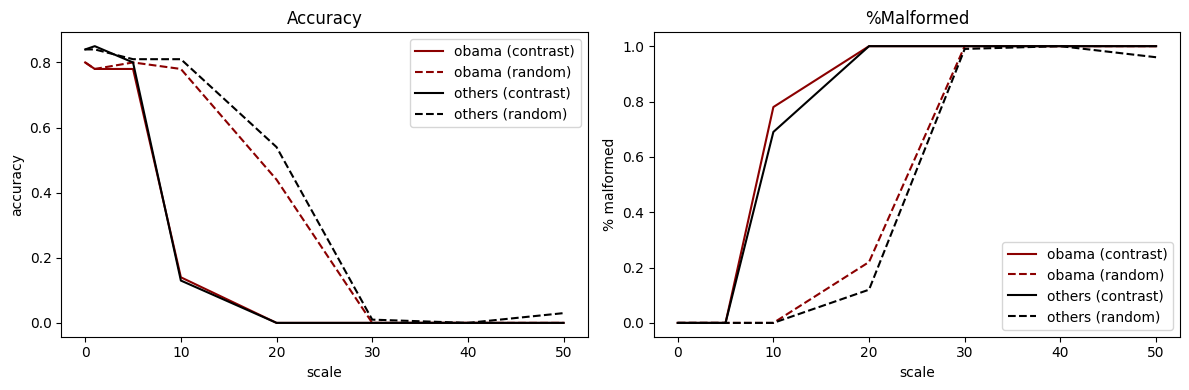

In [69]:
def acc_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "correct"].mean(), df.loc[~mask, "correct"].mean()

def empty_rate_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "parsed"].isna().mean(), df.loc[~mask, "parsed"].isna().mean()

scales = sorted(steered_df["scale"].unique())

# contrast
a_accs_c, o_accs_c, a_empties_c, o_empties_c = [], [], [], []
# random
a_accs_r, o_accs_r, a_empties_r, o_empties_r = [], [], [], []

for s in scales:
    sub_c = steered_df[(steered_df["scale"] == s) & (steered_df["steer_type"] == "contrast")]
    sub_r = steered_df[(steered_df["scale"] == s) & (steered_df["steer_type"] == "random")]
    
    a_acc, o_acc = acc_by_president(sub_c, TARGET)
    a_empty, o_empty = empty_rate_by_president(sub_c, TARGET)
    a_accs_c.append(a_acc)
    o_accs_c.append(o_acc)
    a_empties_c.append(a_empty)
    o_empties_c.append(o_empty)
    
    a_acc, o_acc = acc_by_president(sub_r, TARGET)
    a_empty, o_empty = empty_rate_by_president(sub_r, TARGET)
    a_accs_r.append(a_acc)
    o_accs_r.append(o_acc)
    a_empties_r.append(a_empty)
    o_empties_r.append(o_empty)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(scales, a_accs_c, color="darkred", label="obama (contrast)")
ax1.plot(scales, a_accs_r, color="darkred", linestyle="--", label="obama (random)")
ax1.plot(scales, o_accs_c, color="black", label="others (contrast)")
ax1.plot(scales, o_accs_r, color="black", linestyle="--", label="others (random)")
ax1.set_xlabel("scale")
ax1.set_ylabel("accuracy")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(scales, a_empties_c, color="darkred", label="obama (contrast)")
ax2.plot(scales, a_empties_r, color="darkred", linestyle="--", label="obama (random)")
ax2.plot(scales, o_empties_c, color="black", label="others (contrast)")
ax2.plot(scales, o_empties_r, color="black", linestyle="--", label="others (random)")
ax2.set_xlabel("scale")
ax2.set_ylabel("% malformed")
ax2.set_title("%Malformed")
ax2.legend()

plt.tight_layout()
plt.show()

In [40]:
# steered_df[steered_df["scale"] == 30]

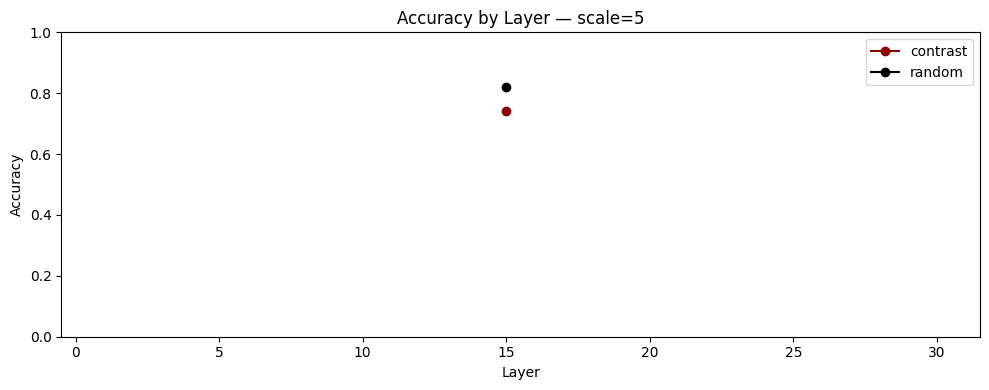

In [53]:
HEATMAP_SCALE = 5

sub_contrast = steered_df[(steered_df["scale"] == HEATMAP_SCALE) & (steered_df["steer_type"] == "contrast")]
sub_random = steered_df[(steered_df["scale"] == HEATMAP_SCALE) & (steered_df["steer_type"] == "random")]

acc_contrast = sub_contrast.groupby("layer")["correct"].mean()
acc_random = sub_random.groupby("layer")["correct"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(acc_contrast.index, acc_contrast.values, color="darkred", marker="o", label="contrast")
ax.plot(acc_random.index, acc_random.values, color="black", marker="o", label="random")
ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title(f"Accuracy by Layer — scale={HEATMAP_SCALE}")
ax.set_xlim(-0.5, 31.5)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# figures

# Data - Simulated from tofu - in context one 
# Data - Claim: we can delete the incontext memeory as well as the embedded memeory


# 3rd -> control analysis, take the dir of vec randomly and repeat 
# Keep some validation to test on unseen
# intcontext vs embedded - show real vs simulated - infering that we can delete from training as well and not jsut prompt context

# Repeat this accross layers
# Repeat accross layers but 32 x 32 heatmap

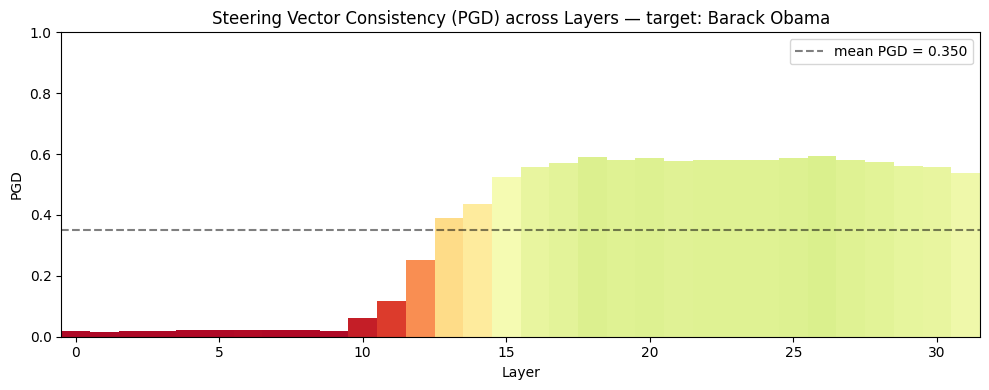

Most consistent layer: 26 (PGD = 0.5938)
Currently used layer 12: PGD = 0.2520


In [42]:
# --- Phase Gradient Directionality (PGD) of steering vectors ---
# PGD(layer) = ||mean(d_i)|| / mean(||d_i||)
# where d_i = bad_acts[i] - good_acts[i] is the per-sample steering vector.
# PGD=1 → all samples agree on direction; PGD→0 → no consistent direction.

good_acts = t.load("store/llama3_pres/good.pt")
bad_acts = t.load("store/llama3_pres/bad.pt")

deltas = bad_acts - good_acts  # (n_samples, num_layers, 1, hidden_dim)
deltas = deltas[:, :, 0, :]   # (n_samples, num_layers, hidden_dim)

num_layers = deltas.shape[1]
pgd = t.zeros(num_layers)

for layer in range(num_layers):
    vecs = deltas[:, layer, :]                        # (n_samples, hidden_dim)
    mag_of_mean = vecs.mean(dim=0).norm()             # ||mean(d_i)||
    mean_of_mag = vecs.norm(dim=1).mean()             # mean(||d_i||)
    pgd[layer] = mag_of_mean / mean_of_mag

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
layers = range(num_layers)
colors = plt.cm.RdYlGn(pgd.numpy())

ax.bar(layers, pgd.numpy(), color=colors, edgecolor="none", width=1.0)
ax.set_xlabel("Layer")
ax.set_ylabel("PGD")
ax.set_title(f"Steering Vector Consistency (PGD) across Layers — target: {TARGET}")
ax.set_xlim(-0.5, num_layers - 0.5)
ax.set_ylim(0, 1)
ax.axhline(y=pgd.mean(), color="black", linestyle="--", alpha=0.5, label=f"mean PGD = {pgd.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

best_layer = pgd.argmax().item()
print(f"Most consistent layer: {best_layer} (PGD = {pgd[best_layer]:.4f})")
print(f"Currently used layer 12: PGD = {pgd[12]:.4f}")

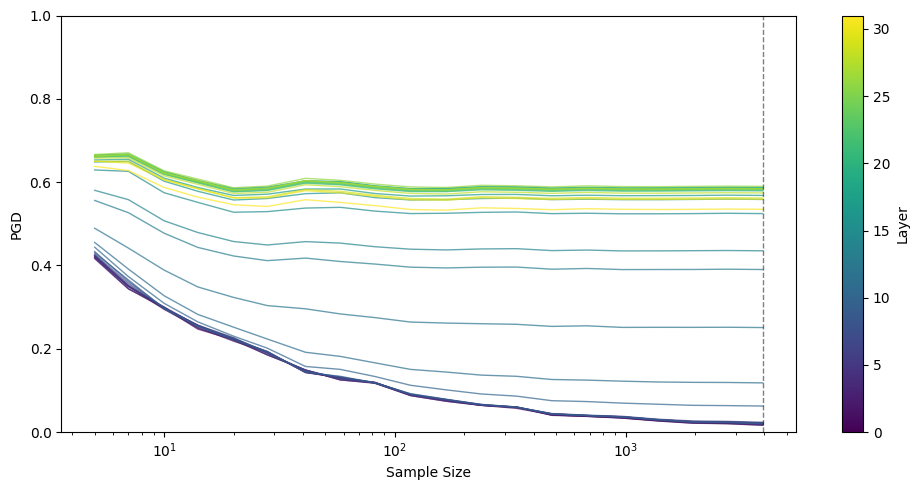

In [44]:
# --- PGD vs Sample Size for all layers ---
import numpy as np

n_total = good_acts.shape[0]
sample_sizes = np.unique(np.geomspace(5, n_total, num=20).astype(int))
n_bootstrap = 30

# pgd_by_n[layer][n] = list of bootstrap PGD values
pgd_by_n = {layer: {n: [] for n in sample_sizes} for layer in range(num_layers)}

for n in sample_sizes:
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_total, size=n, replace=False)
        sub_deltas = deltas[idx]
        for layer in range(num_layers):
            vecs = sub_deltas[:, layer, :].float()
            mag_of_mean = vecs.mean(dim=0).norm().item()
            mean_of_mag = vecs.norm(dim=1).mean().item()
            pgd_by_n[layer][n].append(mag_of_mean / mean_of_mag)

# compute mean PGD per layer per sample size
pgd_means = np.zeros((num_layers, len(sample_sizes)))
for i, n in enumerate(sample_sizes):
    for layer in range(num_layers):
        pgd_means[layer, i] = np.mean(pgd_by_n[layer][n])

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, num_layers))
for layer in range(num_layers):
    ax.plot(sample_sizes, pgd_means[layer], color=cmap[layer], lw=1, alpha=0.7)

ax.axvline(n_total, color="black", ls="--", lw=1, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Sample Size")
ax.set_ylabel("PGD")
ax.set_ylim(0, 1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, num_layers - 1))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Layer")
plt.tight_layout()
plt.show()

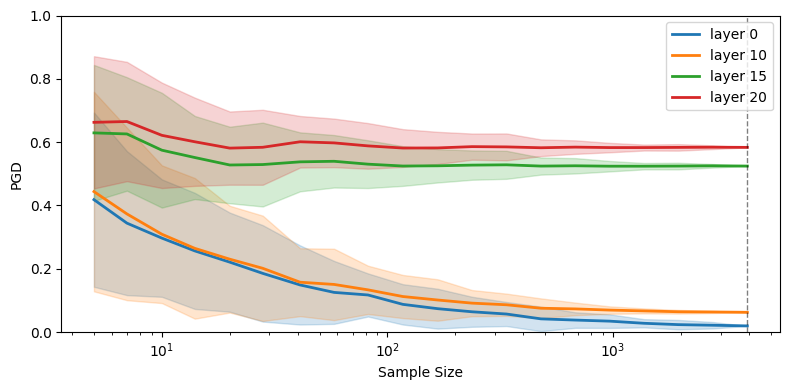

In [48]:
# PGD vs sample size with confidence intervals for selected layers
show_layers = [0, 10, 15, 20, 30]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

pgd_stds = np.zeros((num_layers, len(sample_sizes)))
for i, n in enumerate(sample_sizes):
    for layer in range(num_layers):
        pgd_stds[layer, i] = np.std(pgd_by_n[layer][n])

fig, ax = plt.subplots(figsize=(8, 4))
for layer, color in zip(show_layers, colors):
    mean = pgd_means[layer]
    std = pgd_stds[layer]
    ax.fill_between(sample_sizes, mean - 2*std, mean + 2*std, alpha=0.2, color=color)
    ax.plot(sample_sizes, mean, color=color, lw=2, label=f"layer {layer}")

ax.axvline(n_total, color="black", ls="--", lw=1, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Sample Size")
ax.set_ylabel("PGD")
ax.set_ylim(0, 1)
ax.legend( loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# --- Participation Ratio: effective dimensionality of steering vectors ---
# PR = (Σλ_i)² / Σλ_i²  where λ_i are PCA eigenvalues
# Low PR → vectors live on a low-dim manifold (structured)
# High PR → isotropic / random in full space

import numpy as np

good_acts = t.load("store/llama3_pres/good.pt")
bad_acts = t.load("store/llama3_pres/bad.pt")
deltas = bad_acts - good_acts
deltas = deltas[:, :, 0, :]

n_samples, num_layers, hidden_dim = deltas.shape[0], deltas.shape[1], deltas.shape[2]
n_random_trials = 50

pr_real = np.zeros(num_layers)
pr_random_mean = np.zeros(num_layers)
pr_random_std = np.zeros(num_layers)

for layer in range(num_layers):
    vecs = deltas[:, layer, :].float().numpy()

    # Real PR
    cov = np.cov(vecs, rowvar=True)  # (n_samples, n_samples)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.maximum(eigvals, 0)
    pr_real[layer] = eigvals.sum() ** 2 / (eigvals ** 2).sum()

    # Random baseline: same shape, Gaussian
    pr_trials = []
    for _ in range(n_random_trials):
        rand_vecs = np.random.randn(n_samples, hidden_dim).astype(np.float32)
        cov_r = np.cov(rand_vecs, rowvar=True)
        ev_r = np.linalg.eigvalsh(cov_r)
        ev_r = np.maximum(ev_r, 0)
        pr_trials.append(ev_r.sum() ** 2 / (ev_r ** 2).sum())
    pr_random_mean[layer] = np.mean(pr_trials)
    pr_random_std[layer] = np.std(pr_trials)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(num_layers)

ax.bar(x, pr_real, color="steelblue", edgecolor="none", width=1.0, label="steering vectors")
ax.fill_between(x, pr_random_mean - 2 * pr_random_std, pr_random_mean + 2 * pr_random_std,
                color="gray", alpha=0.3, label="random baseline ±2σ")
ax.axhline(pr_random_mean.mean(), color="gray", ls="--", alpha=0.6)

ax.set_xlabel("Layer")
ax.set_ylabel("Participation Ratio (effective dim)")
ax.set_title(f"Steering Vector Isotropy — target: {TARGET}")
ax.set_xlim(-0.5, num_layers - 0.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max possible PR (n_samples): {n_samples}")
print(f"Mean real PR: {pr_real.mean():.2f}  |  Mean random PR: {pr_random_mean.mean():.2f}")
print(f"Layer 12 PR: {pr_real[12]:.2f}  |  Best PGD layer {best_layer} PR: {pr_real[best_layer]:.2f}")